In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the dataset

In [43]:
df_1 = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


### Preprocessing

In [44]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

In [45]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [46]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

In [47]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

In [48]:
df["EMG"] = df["EMG"].abs()

In [49]:
df = df[df["Temp"] > 0]

In [50]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

# EDA starts here

In [51]:
train.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,4.935773e+06,4.935773e+06,4.935773e+06,4.935773e+06,4.935773e+06,4.935773e+06,4.935773e+06,4.935773e+06,4.935773e+06
mean,7.799649e-01,-4.315937e-02,-4.000913e-01,1.278354e-03,9.833977e-03,3.843815e+00,3.249196e+01,5.583689e-02,2.155535e-01
std,1.438717e-01,8.180436e-02,2.736366e-01,2.235161e-01,1.188797e-02,2.737195e+00,1.946034e+00,3.109452e+00,4.112058e-01
min,3.116000e-01,-4.194000e-01,-1.051000e+00,-1.499405e+00,0.000000e+00,2.632141e-01,2.804526e+01,-2.019653e+01,0.000000e+00
25%,6.454000e-01,-8.279997e-02,-6.904000e-01,-8.747864e-02,2.929688e-03,1.642227e+00,3.132962e+01,-1.649475e+00,0.000000e+00
50%,8.414000e-01,-3.439999e-02,-3.862000e-01,-1.167297e-02,6.637573e-03,2.911758e+00,3.287427e+01,-1.495361e-01,0.000000e+00
75%,8.926001e-01,-1.999974e-03,-1.946000e-01,4.861450e-02,1.277161e-02,6.854248e+00,3.428171e+01,1.817322e+00,0.000000e+00
max,1.380600e+00,5.125999e-01,1.038800e+00,1.499954e+00,1.047180e+00,1.209869e+01,3.514563e+01,1.954193e+01,1.000000e+00


In [52]:
test.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,1.233944e+06,1.233944e+06,1.233944e+06,1.233944e+06,1.233944e+06,1.233944e+06,1.233944e+06,1.233944e+06,1.233944e+06
mean,7.798918e-01,-4.299202e-02,-4.002001e-01,9.701094e-04,9.843791e-03,3.843101e+00,3.249220e+01,5.494660e-02,2.155641e-01
std,1.438546e-01,8.178486e-02,2.736845e-01,2.233156e-01,1.183567e-02,2.737007e+00,1.946958e+00,3.115143e+00,4.112133e-01
min,3.134000e-01,-4.184000e-01,-1.052400e+00,-1.499405e+00,0.000000e+00,4.211426e-01,2.804526e+01,-2.018433e+01,0.000000e+00
25%,6.450000e-01,-8.240002e-02,-6.910000e-01,-8.766174e-02,2.975464e-03,1.642227e+00,3.132962e+01,-1.652527e+00,0.000000e+00
50%,8.414000e-01,-3.420001e-02,-3.862000e-01,-1.176453e-02,6.637573e-03,2.911758e+00,3.287875e+01,-1.525879e-01,0.000000e+00
75%,8.926001e-01,-1.800001e-03,-1.944000e-01,4.866028e-02,1.277161e-02,6.862259e+00,3.428326e+01,1.814270e+00,0.000000e+00
max,1.358200e+00,4.784000e-01,1.041800e+00,1.499954e+00,8.053894e-01,1.206856e+01,3.516263e+01,1.950836e+01,1.000000e+00


In [61]:
from scipy.stats import ks_2samp

def plotSummary(col):
    print(f"------- {col} --------")
    summary = pd.concat(
        [train[col].describe(), test[col].describe()],
        axis=1,
        keys=["Train", "Test"]
    )
    print(summary.to_string())

    # Similarity metrics
    ks_stat, p_value = ks_2samp(train[col].dropna(), test[col].dropna())
    mean_diff = abs(train[col].mean() - test[col].mean())
    std_diff  = abs(train[col].std()  - test[col].std())
    similarity = (1 - ks_stat) * 100

    print(f"\nSimilarity Score : {similarity:.2f}%")
    print(f"KS Statistic     : {ks_stat:.4f}  (lower = more similar)")
    print(f"P-Value          : {p_value:.4f}  ({'similar' if p_value > 0.05 else 'different'} distribution)")
    print(f"Mean Difference  : {mean_diff:.4f}")
    print(f"Std Difference   : {std_diff:.4f}")
    print("\n")

In [62]:
for col in train.columns:
    plotSummary(col)

------- ACC_X --------
              Train          Test
count  4.935773e+06  1.233944e+06
mean   7.799649e-01  7.798918e-01
std    1.438717e-01  1.438546e-01
min    3.116000e-01  3.134000e-01
25%    6.454000e-01  6.450000e-01
50%    8.414000e-01  8.414000e-01
75%    8.926001e-01  8.926001e-01
max    1.380600e+00  1.358200e+00

Similarity Score : 99.94%
KS Statistic     : 0.0006  (lower = more similar)
P-Value          : 0.9202  (similar distribution)
Mean Difference  : 0.0001
Std Difference   : 0.0000


------- ACC_Y --------
              Train          Test
count  4.935773e+06  1.233944e+06
mean  -4.315937e-02 -4.299202e-02
std    8.180436e-02  8.178486e-02
min   -4.194000e-01 -4.184000e-01
25%   -8.279997e-02 -8.240002e-02
50%   -3.439999e-02 -3.420001e-02
75%   -1.999974e-03 -1.800001e-03
max    5.125999e-01  4.784000e-01

Similarity Score : 99.90%
KS Statistic     : 0.0010  (lower = more similar)
P-Value          : 0.3121  (similar distribution)
Mean Difference  : 0.0002
Std Diff

### As you can see train and test dataset is almost identical

In [ ]:
import math

features = train.columns
n = len(features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()  # makes indexing easier

for i, col in enumerate(features):
    axes[i].hist(train[col], bins=20, edgecolor='black')
    axes[i].set_title(col)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [59]:
def plot_hist(col):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(range(len(train[col])), train[col], alpha=0.5, s=10)
    axes[0].set_title(f'Train {col}')

    axes[1].scatter(range(len(test[col])), test[col], alpha=0.5, s=10)
    axes[1].set_title(f'Test {col}')

    plt.tight_layout()
    plt.show()

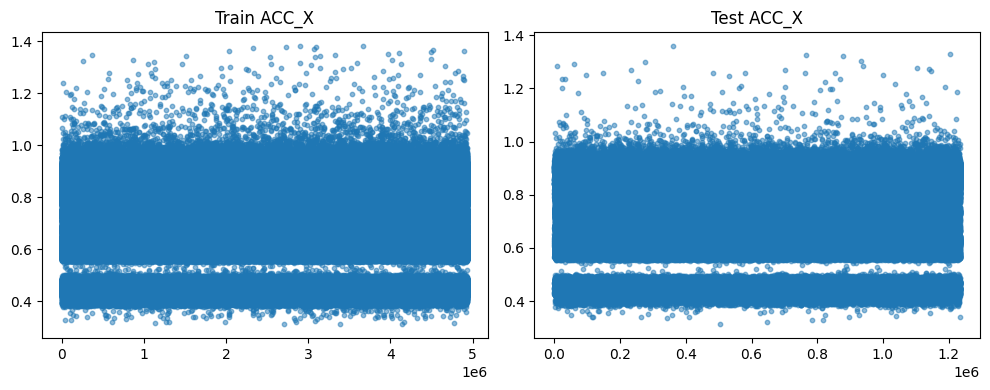

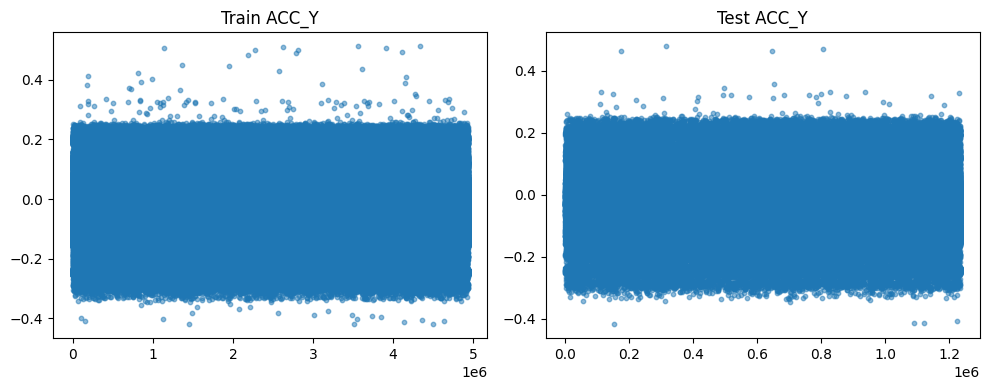

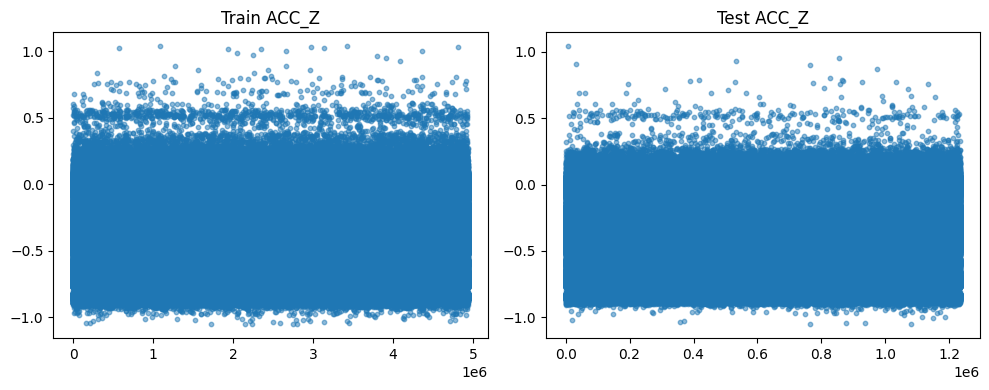

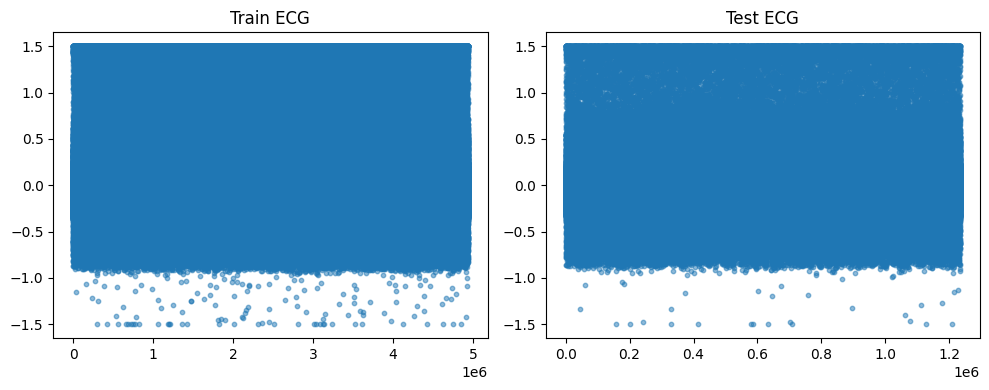

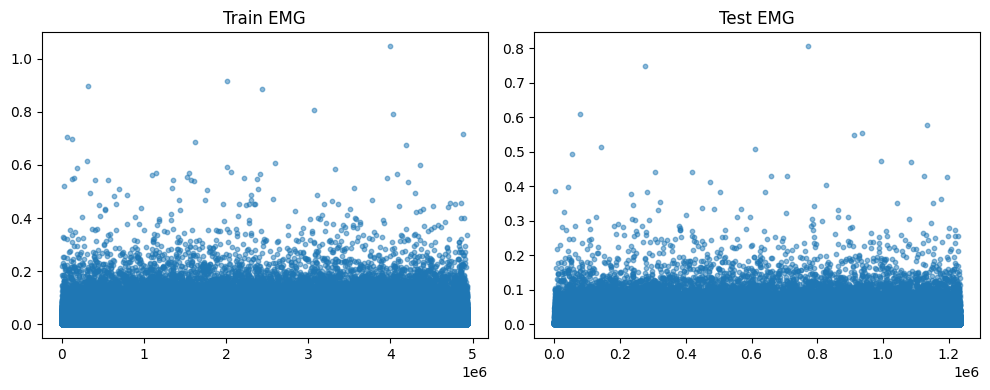

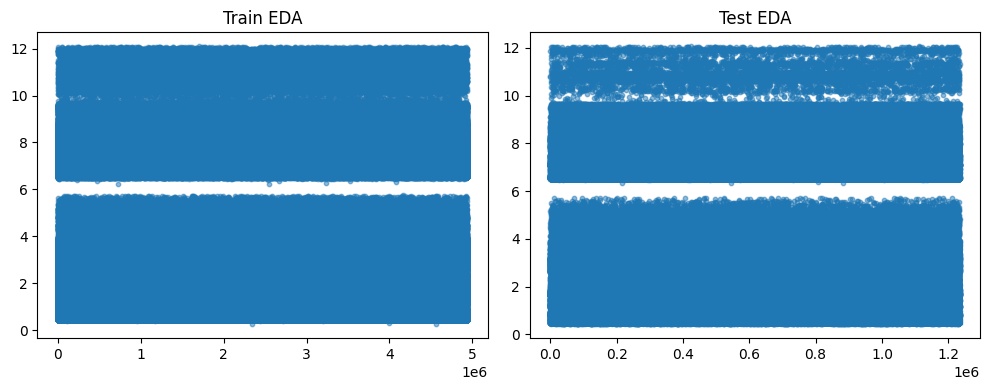

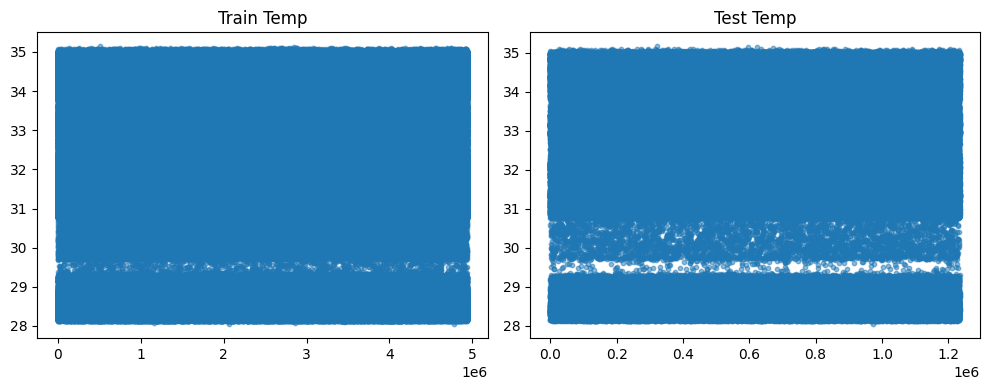

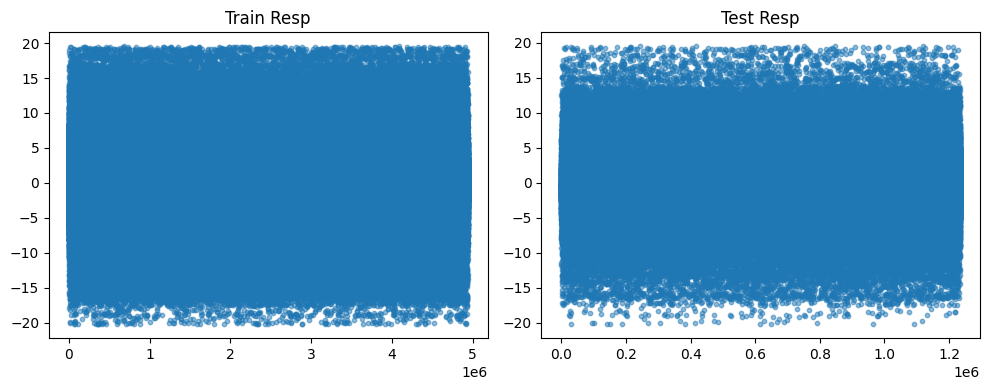

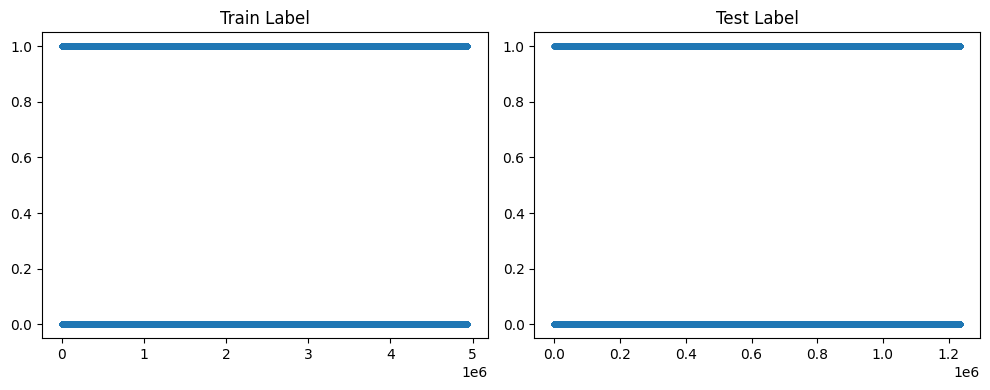

In [60]:
features = df.columns
for col in features:
    plot_hist(col)